# Check whether the model is working

**NOTES:**
- The model needs finetuning before being evaluated.
- Currently only numerical features can be used


In [1]:
import sys

sys.path.append("../")
import shap
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from explainerpfn.base import ExplainerPFN
from explainerpfn.temp import (
    get_data,
    get_shap_values,
    preprocess_data,
    analyze_correlation_results,
    plot_explanations,
)
from explainerpfn.utils import explanation_correction

# just a simple toy dataset (all continuous features)
df, df_train_rf, df_train, df_test = get_data("SPAMBASE")

cols_to_drop = df.columns[4:-1]
df = df.drop(columns=cols_to_drop)
df_train_rf = df_train_rf.drop(columns=cols_to_drop)
df_train = df_train.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)

(X_train_rf, y_train_rf), (X_train, y_train), (X_test, y_test) = preprocess_data(
    df_train_rf, df_train, df_test
)

clf = MLPClassifier(
    max_iter=2000, alpha=0.05, learning_rate="invscaling", random_state=42
)
clf.fit(X_train_rf, y_train_rf)

y_train = clf.predict_proba(X_train)[:, 1]
y_test = clf.predict_proba(X_test)[:, 1]

all_shap_values = []
for X, y in tqdm(
    list(zip([X_train, X_test], [y_train, y_test])), desc="Calculating SHAP values"
):
    xai = shap.Explainer(model=clf.predict_proba, masker=X_train)
    X_shap = xai(X).values[:, :, -1]

    df_shap = pd.DataFrame(X_shap.astype(float), columns=X.columns)
    df_shap["target"] = y
    all_shap_values.append((X_shap, df_shap))

(X_train_shap, df_shap_train), (X_test_shap, df_shap_test) = all_shap_values

Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating SHAP values:   0%|          | 0/2 [00:00<?, ?it/s]

ExactExplainer explainer: 501it [00:29, 16.85it/s]                          
ExactExplainer explainer: 3602it [00:30, 64.79it/s]                           


In [10]:
xai = ExplainerPFN(model_path="../../test_explainerpfn_model.ckp", random_state=42)
xai.fit(X_train, y_train)
explanations = xai.predict(X_test.values, y_test)

In [21]:
# Version 2
from explainerpfn.base import output_correction
from explainerpfn.utils import explanation_correction
from sklearn.linear_model import LinearRegression

explanations_prelinear = (explanations * np.abs(df.corr()["target"].drop("target").values))**2

lr = LinearRegression(fit_intercept=False)
lr.fit(explanations_prelinear, y_test - y_test.mean())
# print(lr.score(X, y))

# explanations_corrected = output_correction(y_test.mean(), explanations, y_test)
# explanations_linear_corrected = output_correction(y_test.mean(), explanations_prelinear * np.abs(lr.coef_), y_test)
explanations_linear = explanations_prelinear * np.abs(lr.coef_)  # * np.sign(df.corr()["target"].drop("target").values) * -1)  # , lr.intercept_
explanations_corrected = explanation_correction(explanations, y_test, y_test.mean(), adjust_std=True)
explanations_linear_corrected = explanation_correction(explanations_prelinear * np.abs(lr.coef_), y_test, y_test.mean(), adjust_std=False)

In [28]:
analyze_correlation_results(
    df, df_shap, explanations, explanations_linear_corrected, y_test, df_train
)

,input_values_vs_target,shap_vs_target,pfn_exp_vs_target,pfn_exp_corr_vs_target,pfn_exp_vs_shap,pfn_exp_corr_vs_shap
0,0.126208,0.503685,-0.127754,0.867113,-0.427449,0.304798
1,-0.030224,0.750538,0.575086,0.766047,0.308360,0.567246
2,0.196988,0.842949,0.137259,0.774076,0.205653,0.635773
3,0.057371,0.163790,0.635672,0.881282,0.172232,0.295564
target,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


(<Figure size 2400x600 with 4 Axes>,
 array([<Axes: xlabel='Input values distribution', ylabel='Frequency'>,
        <Axes: xlabel='PFN explanations distribution', ylabel='Frequency'>,
        <Axes: xlabel='Corrected PFN explanations distribution', ylabel='Frequency'>,
        <Axes: xlabel='SHAP values distribution', ylabel='Frequency'>],
       dtype=object))

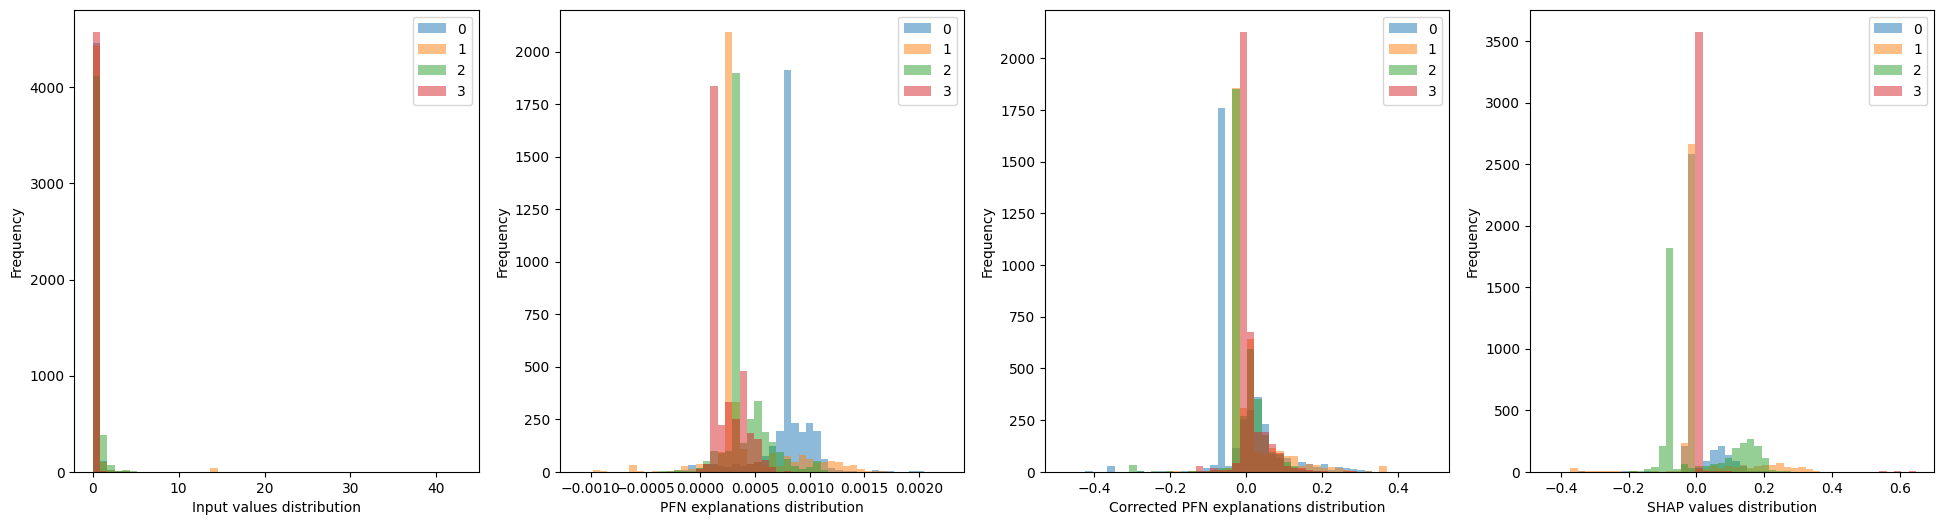

In [29]:
df_explanations = pd.DataFrame(
    explanations.astype(float), columns=df_train.columns.drop("target")
)
df_explanations["target"] = y_test
df_explanations_corrected = pd.DataFrame(
    explanations_corrected.astype(float), columns=df_train.columns.drop("target")
)
df_explanations_corrected["target"] = y_test
plot_explanations(df, df_explanations, df_explanations_corrected, df_shap)

In [30]:
def print_agreement(shap_values, pfn_values):
    # print("Top positive")
    # print("top-1:", (shap_values.argsort(axis=1)[:, -1:] == pfn_values.argsort(axis=1)[:, -1:]).all(axis=1).mean())
    # print("top-2:", (shap_values.argsort(axis=1)[:, -2:] == pfn_values.argsort(axis=1)[:, -2:]).all(axis=1).mean())
    # print("top-3:", (shap_values.argsort(axis=1)[:, -3:] == pfn_values.argsort(axis=1)[:, -3:]).all(axis=1).mean())
    # print("top-4:", (shap_values.argsort(axis=1)[:, -4:] == pfn_values.argsort(axis=1)[:, -4:]).all(axis=1).mean())

    # print("Top negative")
    # print("top-1:", (shap_values.argsort(axis=1)[:, :1] == pfn_values.argsort(axis=1)[:, :1]).all(axis=1).mean())
    # print("top-2:", (shap_values.argsort(axis=1)[:, :2] == pfn_values.argsort(axis=1)[:, :2]).all(axis=1).mean())
    # print("top-3:", (shap_values.argsort(axis=1)[:, :3] == pfn_values.argsort(axis=1)[:, :3]).all(axis=1).mean())
    # print("top-4:", (shap_values.argsort(axis=1)[:, :4] == pfn_values.argsort(axis=1)[:, :4]).all(axis=1).mean())

    print("Top absolute")
    print("top-1:", (np.abs(shap_values).argsort(axis=1)[:, -1:] == np.abs(pfn_values).argsort(axis=1)[:, -1:]).all(axis=1).mean())
    print("top-2:", (np.abs(shap_values).argsort(axis=1)[:, -2:] == np.abs(pfn_values).argsort(axis=1)[:, -2:]).all(axis=1).mean())
    print("top-3:", (np.abs(shap_values).argsort(axis=1)[:, -3:] == np.abs(pfn_values).argsort(axis=1)[:, -3:]).all(axis=1).mean())
    print("top-4:", (np.abs(shap_values).argsort(axis=1)[:, -4:] == np.abs(pfn_values).argsort(axis=1)[:, -4:]).all(axis=1).mean())

In [32]:
print("Agreement; original PFN explanations")
print_agreement(df_shap.drop(columns="target").values, df_explanations.drop(columns="target").values)

print("Agreement; PFN explanations after output correction")
print_agreement(df_shap.drop(columns="target").values, df_explanations_corrected.drop(columns="target").values)

print("Agreement; PFN explanations after linear regression correction")
print_agreement(df_shap.drop(columns="target").values, explanations_linear)

print("Agreement; PFN explanations after linear regression + output correction")
print_agreement(df_shap.drop(columns="target").values, explanations_linear_corrected)

Agreement; original PFN explanations
Top absolute
top-1: 0.09525131907803389
top-2: 0.02527075812274368
top-3: 0.013607331296861983
top-4: 0.013607331296861983
Agreement; PFN explanations after output correction
Top absolute
top-1: 0.09108580949736185
top-2: 0.024159955567897805
top-3: 0.012496528742016106
top-4: 0.012496528742016106
Agreement; PFN explanations after linear regression correction
Top absolute
top-1: 0.04831991113579561
top-2: 0.005554012774229381
top-3: 0.0008331019161344071
top-4: 0.0008331019161344071
Agreement; PFN explanations after linear regression + output correction
Top absolute
top-1: 0.04831991113579561
top-2: 0.005554012774229381
top-3: 0.0008331019161344071
top-4: 0.0008331019161344071
